# Matrix Product Operators: full ITensor approach

In [1]:
using Pkg
Pkg.activate("../")
using ITensors
using ITensorMPS
using Plots

  Activating project at `c:\Users\mariu\GithubCloneTN\TN_Notebooks`


Now we move to business: we use only `ITensor` constructs. We will start from a two spin $1/2$ system considered so far and then move to a larger system.

`ITensor` provides built-in states and operators for a set of physical entities. Please consult [the syte types](https://docs.itensor.org/ITensorMPS/stable/examples/Physics.html) page to get an idea of what is already available and, importantly, of how to extend to custom site types.

Note that in this notebook we will give the understanding of the operational definition of the MPO for granted. So we will never concern us with what is happening behind the scenes.

### 2 Spins:same as in [matrixProductOperators.ipynb](./matrixProductOperators.ipynb)

In [2]:
sites = siteinds("S=1/2",2)

2-element Vector{Index{Int64}}:
 (dim=2|id=362|"S=1/2,Site,n=1")
 (dim=2|id=668|"S=1/2,Site,n=2")

We create the Bell state from scratch

In [3]:
psi1 = MPS(ComplexF64,sites, "Up")
psi2 = MPS(ComplexF64,sites, "Dn")
phiPlus = 1/sqrt(2) * (psi1 + psi2)
matrix(phiPlus[1]*phiPlus[2])


2×2 Matrix{ComplexF64}:
 0.707107+0.0im       0.0+0.0im
      0.0+0.0im  0.707107+0.0im

We now introduce a new object: operators

In [4]:
opsum = OpSum()
opsum += "X", 1,"Z",2
myOp = MPO(opsum, sites)

2-element MPO:
 ((dim=3|id=696|"Link,l=1"), (dim=2|id=362|"S=1/2,Site,n=1")', (dim=2|id=362|"S=1/2,Site,n=1"))
 ((dim=3|id=696|"Link,l=1"), (dim=2|id=668|"S=1/2,Site,n=2")', (dim=2|id=668|"S=1/2,Site,n=2"))

We observe that the resulting MPO is composed by two rank-3 objects sharing the same link index, as expected. The bond dimension is equal to 3, which is the expected bond dimension for a 2-local Hamiltonian (see notes).

In [5]:
out = noprime(myOp * phiPlus)
matrix(out[1]*out[2] )

2×2 Matrix{ComplexF64}:
      0.0+0.0im  -0.707107+0.0im
 0.707107+0.0im        0.0+0.0im

The result is the right one (compare to  [matrixProductOperators.ipynb](./matrixProductOperators.ipynb))

Now we implement  $O + O2$

In [6]:
opsum = OpSum()
opsum += "X",1 ,"Z",2
opsum += "Z",1 ,"Z",2
myOpSum = MPO(opsum, sites)

2-element MPO:
 ((dim=3|id=476|"Link,l=1"), (dim=2|id=362|"S=1/2,Site,n=1")', (dim=2|id=362|"S=1/2,Site,n=1"))
 ((dim=3|id=476|"Link,l=1"), (dim=2|id=668|"S=1/2,Site,n=2")', (dim=2|id=668|"S=1/2,Site,n=2"))

In [7]:
out2 = noprime(myOpSum * phiPlus)
matrix(out2[1]*out2[2] )

2×2 Matrix{ComplexF64}:
 0.707107-0.0im  -0.707107+0.0im
 0.707107+0.0im   0.707107+0.0im

## Extended example

We now simulate an XY model (with $\gamma=0) in the absence of the magnetic field. We take a chain of $N=20$ spins with Hamiltonian:
$$
H = -J \sum_{i=1}^{N-1} \sigma_-^{i} \sigma_+^{i+1} + \sigma_+^{i} \sigma_-^{i+1} 
$$ 
with $J = 1.0$ setting the time-scale ($\hbar = 1$).

Notice that  the presence of a constant magnetic term would add an overall phase factor that does not alter the dynamics.

We initialize the system having the first site "up" and all the remaining elements "down"

In [8]:
nn = 20
jj=1.0
system = siteinds("S=1/2",nn)
#Prepare the initial state as a product state with "Up" on the first site and "Dn" on the rest of the sites
psi0= MPS(ComplexF64,system,[(j==1) ? "Up" : "Dn" for j in 1:nn]);
#Set the orthogonality center to the first site
orthogonalize!(psi0,1)


20-element MPS:
 ((dim=2|id=180|"S=1/2,Site,n=1"), (dim=1|id=324|"Link,l=1"))
 ((dim=2|id=233|"S=1/2,Site,n=2"), (dim=1|id=287|"Link,l=2"), (dim=1|id=324|"Link,l=1"))
 ((dim=2|id=212|"S=1/2,Site,n=3"), (dim=1|id=531|"Link,l=3"), (dim=1|id=287|"Link,l=2"))
 ((dim=2|id=980|"S=1/2,Site,n=4"), (dim=1|id=523|"Link,l=4"), (dim=1|id=531|"Link,l=3"))
 ((dim=2|id=821|"S=1/2,Site,n=5"), (dim=1|id=203|"Link,l=5"), (dim=1|id=523|"Link,l=4"))
 ((dim=2|id=986|"S=1/2,Site,n=6"), (dim=1|id=796|"Link,l=6"), (dim=1|id=203|"Link,l=5"))
 ((dim=2|id=107|"S=1/2,Site,n=7"), (dim=1|id=411|"Link,l=7"), (dim=1|id=796|"Link,l=6"))
 ((dim=2|id=199|"S=1/2,Site,n=8"), (dim=1|id=732|"Link,l=8"), (dim=1|id=411|"Link,l=7"))
 ((dim=2|id=713|"S=1/2,Site,n=9"), (dim=1|id=767|"Link,l=9"), (dim=1|id=732|"Link,l=8"))
 ((dim=2|id=603|"S=1/2,Site,n=10"), (dim=1|id=833|"Link,l=10"), (dim=1|id=767|"Link,l=9"))
 ((dim=2|id=500|"S=1/2,Site,n=11"), (dim=1|id=621|"Link,l=11"), (dim=1|id=833|"Link,l=10"))
 ((dim=2|id=376|"S=1/2,Site

Let's do a test: average value of $\sigma_z$ on all sites (this morally belongs to the next lecture...):

In [9]:
function measureZ(psi::MPS,j::Int)
    #Measured site must be the orthogonality center
    orthogonalize!(psi,j)
    return scalar(dag(psi[j])*noprime(op("Z", system[j])*psi[j]))
end


measureZ (generic function with 1 method)

In [10]:
@show op("Z", system[1])

op("Z", system[1]) = ITensor ord=2
Dim 1: (dim=2|id=180|"S=1/2,Site,n=1")'
Dim 2: (dim=2|id=180|"S=1/2,Site,n=1")
NDTensors.Dense{Float64, Vector{Float64}}
 2×2
 1.0   0.0
 0.0  -1.0



ITensor ord=2 (dim=2|id=180|"S=1/2,Site,n=1")' (dim=2|id=180|"S=1/2,Site,n=1")
NDTensors.Dense{Float64, Vector{Float64}}

In [11]:
function measureProjUp(psi::MPS,j::Int)
    #Measured site must be the orthogonality center
    orthogonalize!(psi,j)
    return scalar(dag(psi[j])*noprime(op("ProjUp", system[j])*psi[j]))
end

function measureProjDn(psi::MPS,j::Int)
    #Measured site must be the orthogonality center
    orthogonalize!(psi,j)
    return scalar(dag(psi[j])*noprime(op("ProjDn", system[j])*psi[j]))
end


measureProjDn (generic function with 1 method)

In [12]:
using Plots

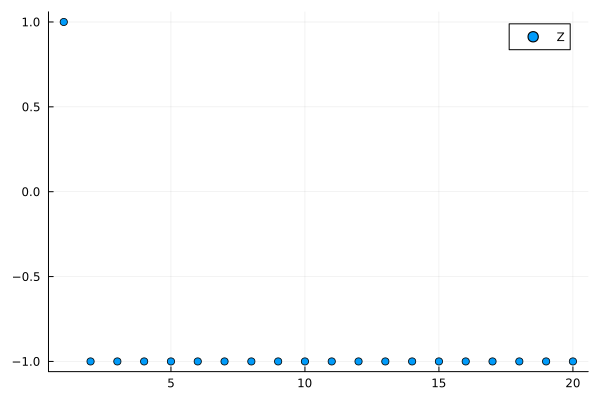

In [13]:
plot(real([measureZ(psi0,j) for j in 1:nn]), seriestype=:scatter, label="Z")

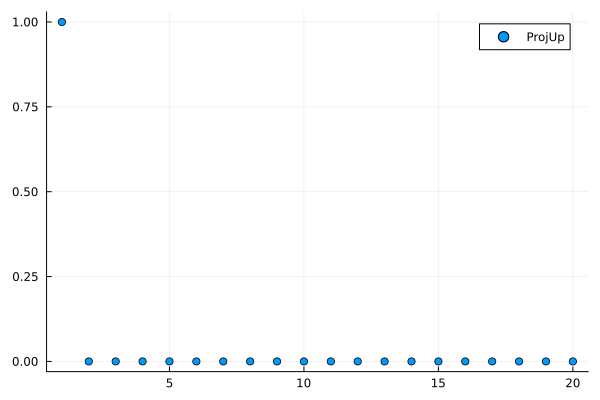

In [14]:
plot(real([measureProjUp(psi0,j) for j in 1:nn]), seriestype=:scatter, label="ProjUp")

Let us now turn our attention to the definition of the MPO.

In [15]:
opsum = OpSum()
for bond in 1:nn-1
    #note that the sintax allows for constants to appear before the operator string
    opsum += -1. * jj, "S-", bond, "S+", bond+1
    opsum += -1. * jj, "S+", bond, "S-", bond+1
end
ham = MPO(opsum, system);

In [16]:
ham

20-element MPO:
 ((dim=4|id=714|"Link,l=1"), (dim=2|id=180|"S=1/2,Site,n=1")', (dim=2|id=180|"S=1/2,Site,n=1"))
 ((dim=4|id=714|"Link,l=1"), (dim=4|id=83|"Link,l=2"), (dim=2|id=233|"S=1/2,Site,n=2")', (dim=2|id=233|"S=1/2,Site,n=2"))
 ((dim=4|id=83|"Link,l=2"), (dim=4|id=382|"Link,l=3"), (dim=2|id=212|"S=1/2,Site,n=3")', (dim=2|id=212|"S=1/2,Site,n=3"))
 ((dim=4|id=382|"Link,l=3"), (dim=4|id=555|"Link,l=4"), (dim=2|id=980|"S=1/2,Site,n=4")', (dim=2|id=980|"S=1/2,Site,n=4"))
 ((dim=4|id=555|"Link,l=4"), (dim=4|id=862|"Link,l=5"), (dim=2|id=821|"S=1/2,Site,n=5")', (dim=2|id=821|"S=1/2,Site,n=5"))
 ((dim=4|id=862|"Link,l=5"), (dim=4|id=607|"Link,l=6"), (dim=2|id=986|"S=1/2,Site,n=6")', (dim=2|id=986|"S=1/2,Site,n=6"))
 ((dim=4|id=607|"Link,l=6"), (dim=4|id=637|"Link,l=7"), (dim=2|id=107|"S=1/2,Site,n=7")', (dim=2|id=107|"S=1/2,Site,n=7"))
 ((dim=4|id=637|"Link,l=7"), (dim=4|id=494|"Link,l=8"), (dim=2|id=199|"S=1/2,Site,n=8")', (dim=2|id=199|"S=1/2,Site,n=8"))
 ((dim=4|id=494|"Link,l=8"), 

We can now see the action of the Hamiltonian on the initial state:

In [17]:
psi1 = noprime(ham * psi0);
norm(psi1)

1.0

In [18]:
psi1

20-element MPS:
 ((dim=1|id=256|"Link,l=1"), (dim=2|id=180|"S=1/2,Site,n=1"))
 ((dim=2|id=233|"S=1/2,Site,n=2"), (dim=1|id=283|"Link,l=2"), (dim=1|id=256|"Link,l=1"))
 ((dim=2|id=212|"S=1/2,Site,n=3"), (dim=1|id=273|"Link,l=3"), (dim=1|id=283|"Link,l=2"))
 ((dim=2|id=980|"S=1/2,Site,n=4"), (dim=1|id=394|"Link,l=4"), (dim=1|id=273|"Link,l=3"))
 ((dim=2|id=821|"S=1/2,Site,n=5"), (dim=1|id=182|"Link,l=5"), (dim=1|id=394|"Link,l=4"))
 ((dim=2|id=986|"S=1/2,Site,n=6"), (dim=1|id=437|"Link,l=6"), (dim=1|id=182|"Link,l=5"))
 ((dim=2|id=107|"S=1/2,Site,n=7"), (dim=1|id=947|"Link,l=7"), (dim=1|id=437|"Link,l=6"))
 ((dim=2|id=199|"S=1/2,Site,n=8"), (dim=1|id=386|"Link,l=8"), (dim=1|id=947|"Link,l=7"))
 ((dim=2|id=713|"S=1/2,Site,n=9"), (dim=1|id=741|"Link,l=9"), (dim=1|id=386|"Link,l=8"))
 ((dim=2|id=603|"S=1/2,Site,n=10"), (dim=1|id=142|"Link,l=10"), (dim=1|id=741|"Link,l=9"))
 ((dim=2|id=500|"S=1/2,Site,n=11"), (dim=1|id=865|"Link,l=11"), (dim=1|id=142|"Link,l=10"))
 ((dim=2|id=376|"S=1/2,Site

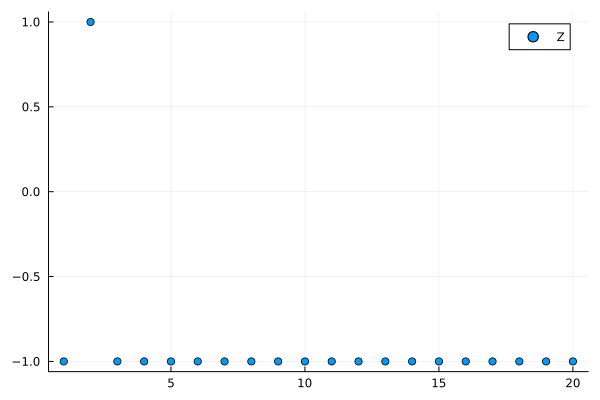

In [19]:
plot(real( [measureZ(psi1,j) for j in 1:nn]), seriestype=:scatter, label="Z")

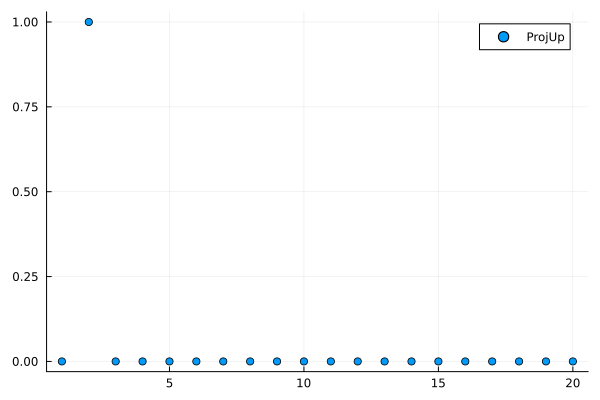

In [20]:
plot(real([measureProjUp(psi1,j) for j in 1:nn]), seriestype=:scatter, label="ProjUp")

Let's apply the Hamiltonian one more time:

In [21]:
psi2 = noprime(ham * psi1);
norm(psi2)

1.4142135623730951

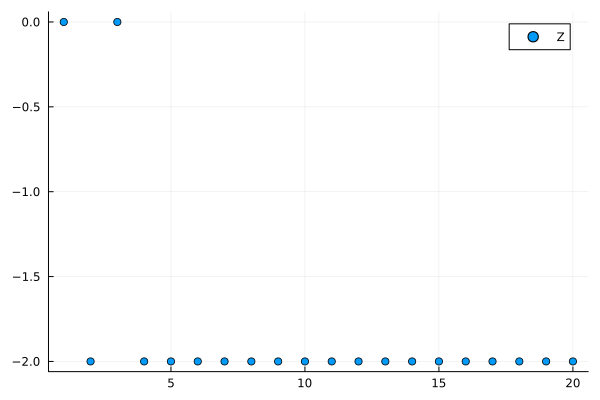

In [22]:
plot(real([measureZ(psi2,j) for j in 1:nn]), seriestype=:scatter, label="Z")

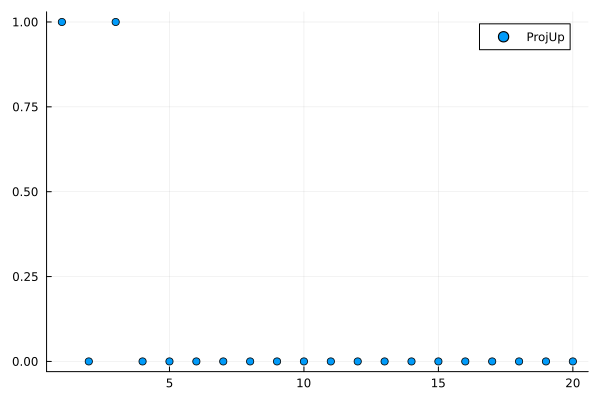

In [23]:
plot(real([measureProjUp(psi2,j) for j in 1:nn]), seriestype=:scatter, label="ProjUp")

We know something about the Ising model. For example we know that the number of spin "up" (or "down") is a constant of the motion, i.e. it commutes with the Hamiltonian. Let's see if this holds at least for some power of $H$

In [24]:
nupOp = OpSum()
for j in 1:nn
    nupOp += 1.0, "ProjUp", j
end
nupMPO = MPO(nupOp, system);

In [25]:
inner(psi0',nupMPO,psi0)

1.0 + 0.0im

In [26]:
inner(psi1',nupMPO,psi1)

1.0 + 0.0im

...so far so good.

We now push a little forward. Suppose that we want to _evolve_ the state $\ket{\psi_0}$ under the action of $H$ for a time $\delta t$.

Since
$$
\exp(-i H \delta t) = \mathbb{1} -i H \delta t -\frac{1}{2} \left ( H \delta t \right )^2 + .. = \sum_k=\frac{(-i)^k}{k!} \left( H \delta t\right)^k
$$
for $\delta t $ small enough we could be satisfied with an order 3 ($k=0,1,2,3$) approximation of the expansion.


In [27]:
deltat = 0.1
nsteps = Int(round(10/deltat))
hdeltat = deltat * ham
#build an MPO with the operator "Id" on each site
theOne = MPO(system,"Id")
factor(k) = (-1im)^k / factorial(k)
#As not to have all the indices of hdeltat contracted with each other, we prime the second one and then we contract the first index of the second one with the first index of the first one, and then we lower the second prime level to first prime level.
h2 = mapprime(prime(hdeltat)*hdeltat,2 =>1)
h3 = mapprime(prime(hdeltat) * h2,2 =>1)
terms = [theOne, factor(1)*hdeltat, factor(2)*h2, factor(3)*h3];
appo = terms[1];
for t in terms[2:end]
    appo = t + appo
end
h4thOrder = appo;
#h4thOrder = +(terms...; cutoff=1e-18);

20-element MPO:
 ((dim=2|id=180|"S=1/2,Site,n=1")', (dim=2|id=180|"S=1/2,Site,n=1"), (dim=8|id=745|"Link,l=1"))
 ((dim=2|id=233|"S=1/2,Site,n=2")', (dim=2|id=233|"S=1/2,Site,n=2"), (dim=18|id=578|"Link,l=2"), (dim=8|id=745|"Link,l=1"))
 ((dim=2|id=212|"S=1/2,Site,n=3")', (dim=2|id=212|"S=1/2,Site,n=3"), (dim=14|id=59|"Link,l=3"), (dim=18|id=578|"Link,l=2"))
 ((dim=2|id=980|"S=1/2,Site,n=4")', (dim=2|id=980|"S=1/2,Site,n=4"), (dim=14|id=479|"Link,l=4"), (dim=14|id=59|"Link,l=3"))
 ((dim=2|id=821|"S=1/2,Site,n=5")', (dim=2|id=821|"S=1/2,Site,n=5"), (dim=16|id=299|"Link,l=5"), (dim=14|id=479|"Link,l=4"))
 ((dim=2|id=986|"S=1/2,Site,n=6")', (dim=2|id=986|"S=1/2,Site,n=6"), (dim=14|id=897|"Link,l=6"), (dim=16|id=299|"Link,l=5"))
 ((dim=2|id=107|"S=1/2,Site,n=7")', (dim=2|id=107|"S=1/2,Site,n=7"), (dim=14|id=169|"Link,l=7"), (dim=14|id=897|"Link,l=6"))
 ((dim=2|id=199|"S=1/2,Site,n=8")', (dim=2|id=199|"S=1/2,Site,n=8"), (dim=14|id=788|"Link,l=8"), (dim=14|id=169|"Link,l=7"))
 ((dim=2|id=713|

Let us evolve the initial state for one time step $\delta t$

In [28]:
psideltat = noprime(h4thOrder * psi0)

20-element MPS:
 ((dim=2|id=976|"Link,l=1"), (dim=2|id=180|"S=1/2,Site,n=1"))
 ((dim=2|id=233|"S=1/2,Site,n=2"), (dim=2|id=203|"Link,l=2"), (dim=2|id=976|"Link,l=1"))
 ((dim=2|id=212|"S=1/2,Site,n=3"), (dim=2|id=624|"Link,l=3"), (dim=2|id=203|"Link,l=2"))
 ((dim=2|id=980|"S=1/2,Site,n=4"), (dim=1|id=232|"Link,l=4"), (dim=2|id=624|"Link,l=3"))
 ((dim=2|id=821|"S=1/2,Site,n=5"), (dim=1|id=76|"Link,l=5"), (dim=1|id=232|"Link,l=4"))
 ((dim=2|id=986|"S=1/2,Site,n=6"), (dim=1|id=409|"Link,l=6"), (dim=1|id=76|"Link,l=5"))
 ((dim=2|id=107|"S=1/2,Site,n=7"), (dim=1|id=897|"Link,l=7"), (dim=1|id=409|"Link,l=6"))
 ((dim=2|id=199|"S=1/2,Site,n=8"), (dim=1|id=537|"Link,l=8"), (dim=1|id=897|"Link,l=7"))
 ((dim=2|id=713|"S=1/2,Site,n=9"), (dim=1|id=289|"Link,l=9"), (dim=1|id=537|"Link,l=8"))
 ((dim=2|id=603|"S=1/2,Site,n=10"), (dim=1|id=926|"Link,l=10"), (dim=1|id=289|"Link,l=9"))
 ((dim=2|id=500|"S=1/2,Site,n=11"), (dim=1|id=436|"Link,l=11"), (dim=1|id=926|"Link,l=10"))
 ((dim=2|id=376|"S=1/2,Site,n

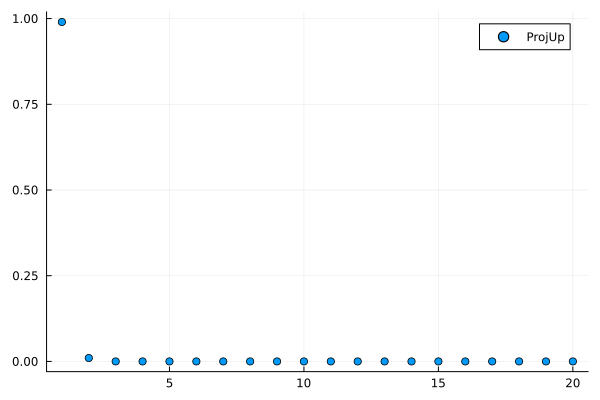

In [29]:
plot(real([measureProjUp(psideltat,j) for j in 1:nn]), seriestype=:scatter, label="ProjUp")

little happened

In [30]:
psi2deltat = noprime(h4thOrder * psideltat)

20-element MPS:
 ((dim=2|id=72|"Link,l=1"), (dim=2|id=180|"S=1/2,Site,n=1"))
 ((dim=2|id=233|"S=1/2,Site,n=2"), (dim=2|id=606|"Link,l=2"), (dim=2|id=72|"Link,l=1"))
 ((dim=2|id=212|"S=1/2,Site,n=3"), (dim=2|id=266|"Link,l=3"), (dim=2|id=606|"Link,l=2"))
 ((dim=2|id=980|"S=1/2,Site,n=4"), (dim=2|id=272|"Link,l=4"), (dim=2|id=266|"Link,l=3"))
 ((dim=2|id=821|"S=1/2,Site,n=5"), (dim=2|id=355|"Link,l=5"), (dim=2|id=272|"Link,l=4"))
 ((dim=2|id=986|"S=1/2,Site,n=6"), (dim=1|id=97|"Link,l=6"), (dim=2|id=355|"Link,l=5"))
 ((dim=2|id=107|"S=1/2,Site,n=7"), (dim=1|id=682|"Link,l=7"), (dim=1|id=97|"Link,l=6"))
 ((dim=2|id=199|"S=1/2,Site,n=8"), (dim=1|id=613|"Link,l=8"), (dim=1|id=682|"Link,l=7"))
 ((dim=2|id=713|"S=1/2,Site,n=9"), (dim=1|id=456|"Link,l=9"), (dim=1|id=613|"Link,l=8"))
 ((dim=2|id=603|"S=1/2,Site,n=10"), (dim=1|id=217|"Link,l=10"), (dim=1|id=456|"Link,l=9"))
 ((dim=2|id=500|"S=1/2,Site,n=11"), (dim=1|id=5|"Link,l=11"), (dim=1|id=217|"Link,l=10"))
 ((dim=2|id=376|"S=1/2,Site,n=12"

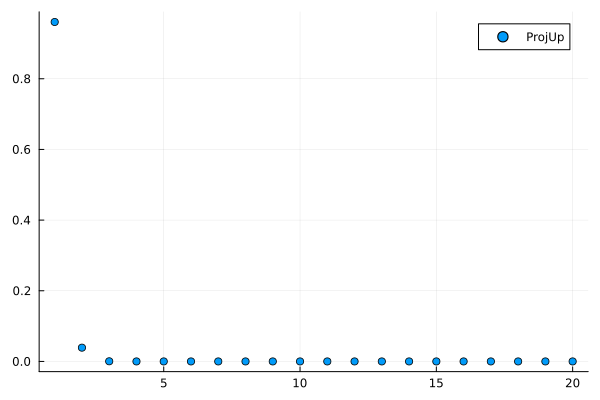

In [31]:
plot(real([measureProjUp(psi2deltat,j) for j in 1:nn]), seriestype=:scatter, label="ProjUp")

fast forward:

In [32]:
evolved = Vector{MPS}()
push!(evolved, psi0)
for j=2:nsteps
    push!(evolved, noprime(h4thOrder * evolved[end]))
end

┌ Info: Saved animation to c:\Users\mariu\GithubCloneTN\TN_Notebooks\Lecture3\evolution.gif
└ @ Plots C:\Users\mariu\.julia\packages\Plots\GIume\src\animation.jl:156


Plots.AnimatedGif("c:\\Users\\mariu\\GithubCloneTN\\TN_Notebooks\\Lecture3\\evolution.gif")
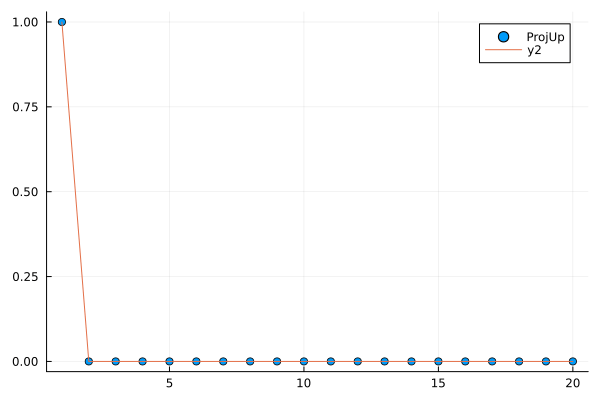

In [43]:
anim = @animate for i=1:nsteps
    fig = plot(real([measureProjUp(evolved[i],j) for j in 1:nn]), seriestype=:scatter, label="ProjUp")
    plot!(fig, real([measureProjUp(evolved[i],j) for j in 1:nn]))
end;
gif(anim, "evolution.gif", fps=10)

Inspect the norm

In [34]:
norm.(evolved)

100-element Vector{Float64}:
 1.0
 0.9999917360769243
 0.9999834725620013
 0.9999752094552103
 0.9999669467564987
 0.9999586844659036
 0.9999504225833267
 0.9999421611088112
 0.9999339000422784
 0.9999256393837346
 ⋮
 0.9992496511401501
 0.9992414242494001
 0.9992331977643899
 0.9992249716850924
 0.9992167460114852
 0.9992085207435413
 0.9992002958812339
 0.9991920714245334
 0.9991838473734072

Total number of spin up:

In [35]:
[inner(a',nupMPO,a)/norm(a) for a in evolved]

100-element Vector{ComplexF64}:
                1.0 + 0.0im
 0.9999917360769243 + 0.0im
 0.9999834725620005 + 0.0im
 0.9999752094552073 - 5.550977507956415e-17im
 0.9999669467564972 + 4.0388343337512093e-28im
 0.9999586844659034 + 1.009700240632032e-28im
 0.9999504225833249 - 5.5508399130167656e-17im
 0.9999421611088094 + 1.1755623440447904e-38im
 0.9999339000422781 - 5.5507481946508366e-17im
 0.9999256393837329 + 5.550702338784263e-17im
                    ⋮
 0.9992496511401501 + 1.7360261011824992e-17im
 0.9992414242493997 + 3.472080788243699e-18im
 0.9992331977643898 + 3.472109373183254e-17im
 0.9992249716850935 + 0.0im
 0.9992167460114835 + 6.944333080490098e-18im
 0.9992085207435412 + 0.0im
  0.999200295881232 + 1.3888894814202482e-17im
 0.9991920714245325 + 0.0im
  0.999183847373406 + 4.166737035720362e-17im

We have an exact solution of the isotropic Ising chain.

In [36]:
eigVals(n,k) = -2*jj*cos(k * π / (n+1))
eigVecs(n,k) = sqrt(2/(n+1)) * [sin(j * k * π / (n+1)) for j in 1:n]

eigVecs (generic function with 1 method)

In [37]:
norm(eigVecs(20,1)  )

0.9999999999999999

In [38]:
exactSol(n,t,init::Vector{ComplexF64}) = sum(exp(-1im * eigVals(n,k) * t) * eigVecs(n,k)* eigVecs(n,k)' * init for k in 1:n) 

exactSol (generic function with 1 method)

In [39]:
[norm(exactSol(nn,0.1*(i-1), ComplexF64.([1.0; zeros(nn-1)]))) for i=1:100]

100-element Vector{Float64}:
 0.9999999999999999
 0.9999999999999999
 1.0
 1.0
 1.0
 0.9999999999999999
 1.0
 1.0
 1.0
 1.0000000000000002
 ⋮
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0000000000000002
 1.0
 1.0000000000000002
 1.0000000000000002

In [40]:
anim = @animate for i=1:nsteps
    fig = plot(real([measureProjUp(evolved[i],j) for j in 1:nn]), seriestype=:scatter, label="MPO")
    plot!(fig, real([measureProjUp(evolved[i],j) for j in 1:nn]),label="MPO")
    plot!(fig, abs.(exactSol(nn,deltat*(i-1), ComplexF64.([1.0; zeros(nn-1)]))) .^ 2, label="Exact")
    plot!(fig, (abs.(exactSol(nn,deltat*(i-1), ComplexF64.([1.0; zeros(nn-1)])))).^ 2, label="Exact",seriestype=:scatter)
end;
gif(anim, "evolutionCheck.gif", fps=10);

┌ Info: Saved animation to c:\Users\mariu\GithubCloneTN\TN_Notebooks\Lecture3\evolutionCheck.gif
└ @ Plots C:\Users\mariu\.julia\packages\Plots\GIume\src\animation.jl:156
